In [2]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import math
import seaborn as sns
import re
from scipy.stats import zscore
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from scipy.stats import zscore

# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private playlist-read-private",
                                               requests_timeout=30))

In [3]:
comp = pd.read_csv(r'./data/pennstahtspring2025/competitors.csv')
roun = pd.read_csv(r'./data/pennstahtspring2025/rounds.csv')
subm = pd.read_csv(r'./data/pennstahtspring2025/submissions.csv')
vote = pd.read_csv(r'./data/pennstahtspring2025/votes.csv')

#subb = subm[['Spotify URI','Submitter ID','Round ID']].rename(columns={'Submitter ID':'Voter ID'})
#subb['Points Assigned'] = 5
#vote = pd.concat([subb,vote])

vote = vote.merge(comp,left_on='Voter ID',right_on='ID').drop(columns='ID')
roun1 = roun[['ID','Name']].rename(columns={'ID':'Round ID','Name': 'Round'})

vote = vote.merge(roun1,on='Round ID')

votesum = vote.groupby(['Round ID','Name'])['Points Assigned'].agg('sum').reset_index()
votesum = votesum[votesum['Points Assigned']>100].drop(columns='Points Assigned')

df_filtered = vote.merge(votesum, on=['Round ID', 'Name'], how='left', indicator=True)
df_filtered = df_filtered[df_filtered['Name']!='Anna Render']
vote = df_filtered[df_filtered['_merge'] == 'left_only'].drop(columns=['_merge'])

# Merge Submitter ID from subm into vote
vote = vote.merge(subm[['Spotify URI', 'Submitter ID']], on='Spotify URI', how='left')
vote = vote[vote['Round ID'] != 'c9d49401f19e49599652e40875a76b14']
#vote = vote[vote['Points Assigned'] != -1]

# Merge Submitter Name (Name column) from comp into vote
vote = vote.merge(comp[['ID', 'Name']].rename(columns={'ID': 'Submitter ID', 'Name': 'Submitter Name'}), on='Submitter ID', how='left')

# Extract unique Spotify URIs from the vote DataFrame
unique_uris = vote['Spotify URI'].unique()

# Initialize an empty dictionary to store play counts
play_counts = {}

# Spotify API allows up to 50 tracks per request, so process in batches
batch_size = 50
for i in range(0, len(unique_uris), batch_size):
    batch = unique_uris[i:i + batch_size]
    # Fetch track details for the batch
    results = sp.tracks(batch)
    for track in results['tracks']:
        if track:  # Ensure the track exists
            play_counts[track['uri']] = track['popularity']  # Popularity is a proxy for play count

# Map play counts to the vote DataFrame
vote['Play Count'] = vote['Spotify URI'].map(play_counts)/100

# Group by 'Spotify URI' and calculate the sum of 'Points Assigned' and mean of 'Play Count'
grouped_by_song = vote.groupby(['Spotify URI', 'Submitter Name','Round ID']).agg({
    'Points Assigned': 'sum',
    'Play Count': 'mean'
}).reset_index()

# Rename columns for clarity
grouped_by_song.rename(columns={
    'Points Assigned': 'Total Points',
    'Play Count': 'Average Popularity'
}, inplace=True)


grouped_by_song['PopularityZ'] = zscore(grouped_by_song['Average Popularity'])
grouped_by_song['TotalPointsZ'] = zscore(grouped_by_song['Total Points'])
grouped_by_song['Track ID'] = grouped_by_song['Spotify URI'].apply(lambda x: re.sub(r'spotify:track:', '', x))



In [4]:


# Use client credentials (not user OAuth)
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id="f6f6de34e09741d28b1766703ec2560a",
    client_secret="19cd0d5906204557934a27406a24e4ca"
))

# Extract raw track IDs from full URIs
def extract_track_id(uri):
    return uri.split(":")[-1] if isinstance(uri, str) and "spotify:track:" in uri else None

vote['Track ID'] = vote['Spotify URI'].apply(extract_track_id)
unique_ids = vote['Track ID'].dropna().unique()

track_data = []
audio_features = []

batch_size = 50

# Fetch track metadata (popularity)
for i in range(0, len(unique_ids), batch_size):
    batch = unique_ids[i:i + batch_size]
    results = sp.tracks(batch)
    for track in results['tracks']:
        if track:
            track_data.append({
                'Track ID': track['id'],
                'Popularity': track['popularity'],
                'duration_ms': track['duration_ms'],
                'explicit': track['explicit']
            })

# Merge metadata and features
track_df = pd.DataFrame(track_data)

# Merge with vote data
vote = vote.merge(track_df, on='Track ID', how='left')

# Z-score normalization
vote['PopularityZ'] = zscore(vote['Popularity'], nan_policy='omit')
vote['TotalPointsZ'] = zscore(vote['Points Assigned'], nan_policy='omit')
vote['AdjustedScoreZ'] = vote['TotalPointsZ'] - vote['PopularityZ']


In [5]:
grouped_by_song = grouped_by_song.merge(track_df, on='Track ID', how='left')
tdf = grouped_by_song.groupby('Submitter Name').agg({'Total Points': 'sum', 'Popularity': 'mean', 'explicit': 'sum','duration_ms':'mean'}).reset_index()
tdf['duration_ms'] = tdf['duration_ms'] / 60000  # Convert ms to minutes

In [6]:
tdf

,Submitter Name,Total Points,Popularity,explicit,duration_ms
0,Anna Render,2,40.000000,0,2.768333
1,Cam Mallett,108,53.000000,3,4.021911
2,Emily Lundstrom,172,65.416667,4,3.803721
3,Erika Frees,232,65.333333,2,3.823276
4,FedEx Pope,146,49.000000,2,4.371718
5,Jiggy Gosalia,190,61.636364,3,4.979365
6,Maggi,161,65.454545,1,3.685861
7,Nathalie Kirby,170,53.545455,2,3.244312
8,Nick Kitchen,162,53.090909,3,4.221538
9,Patrick Thomas,151,34.636364,4,3.605288


<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ajwin\AppData\Local\Temp\ipykernel_10184\149572591.py:34: SyntaxWarning: invalid escape sequence '\h'
  plt.savefig(outdir+'\heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_10184\149572591.py:34: UserWarning: Glyph 127801 (\N{ROSE}) missing from font(s) DejaVu Sans.
  plt.savefig(outdir+'\heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_10184\149572591.py:34: UserWarning: Glyph 129655 (\N{PINK HEART}) missing from font(s) DejaVu Sans.
  plt.savefig(outdir+'\heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_10184\149572591.py:34: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.savefig(outdir+'\heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_10184\149572591.py:34: UserWarning: Glyph 127997 (\N{EMOJI MODIFIE

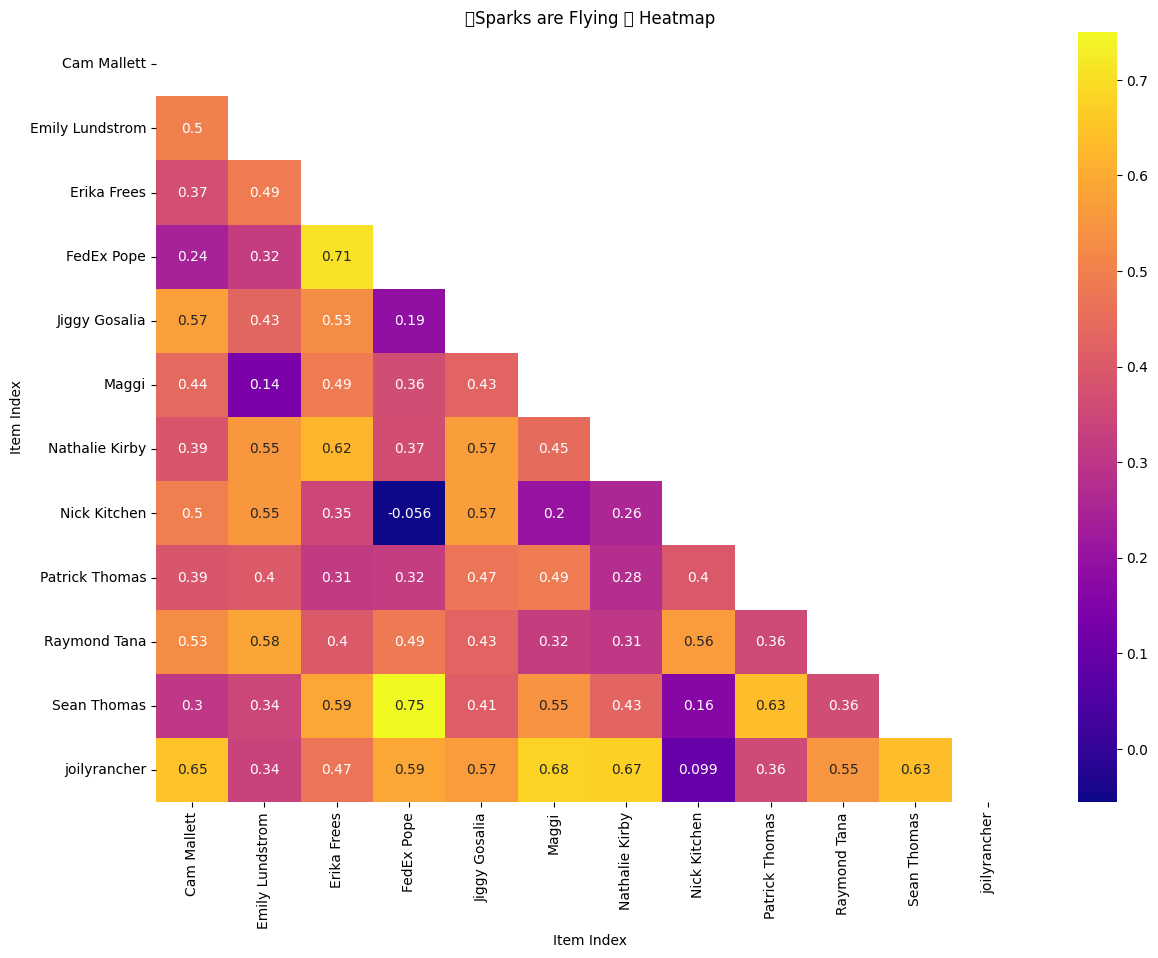

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127997 (\N{EMOJI MODIFIER FITZPATRICK TYPE-4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


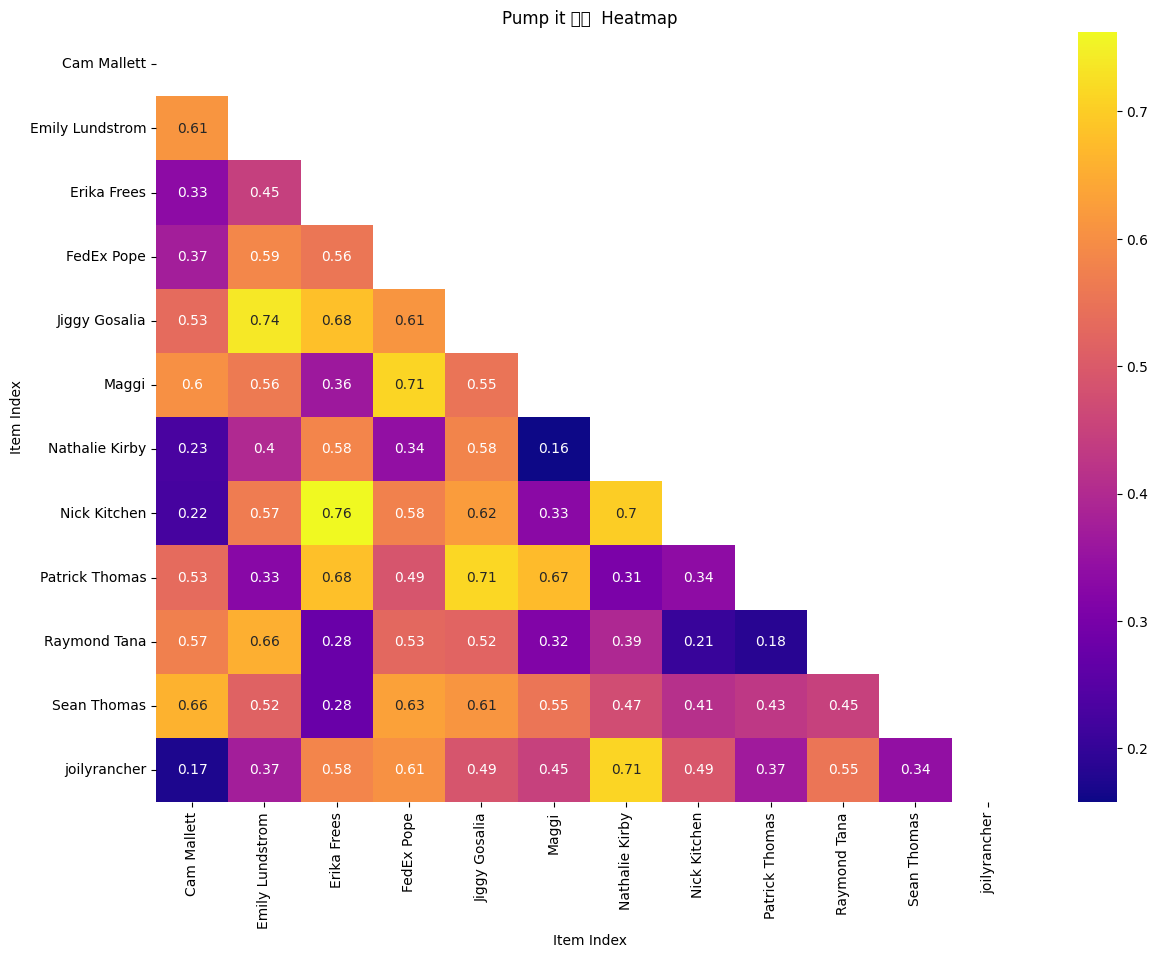

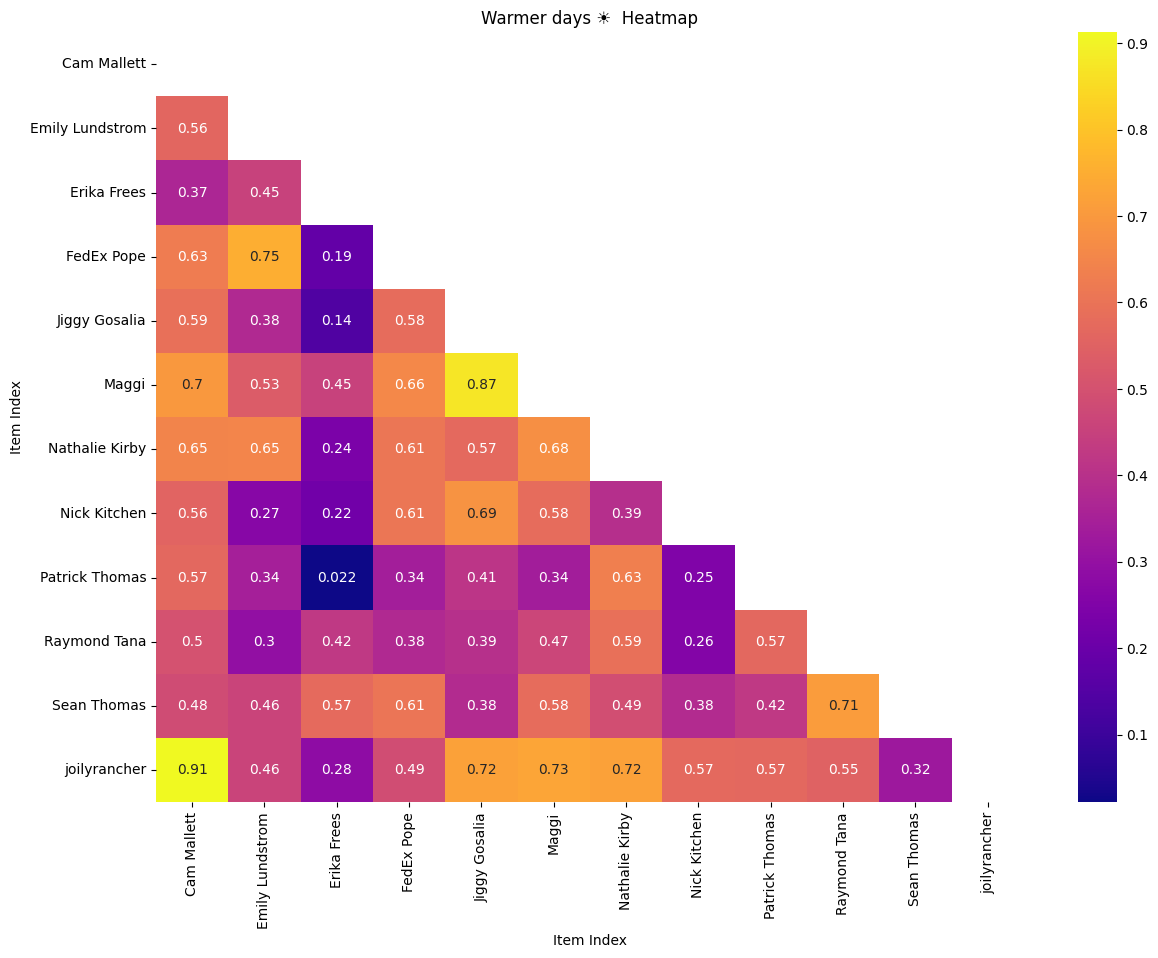

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


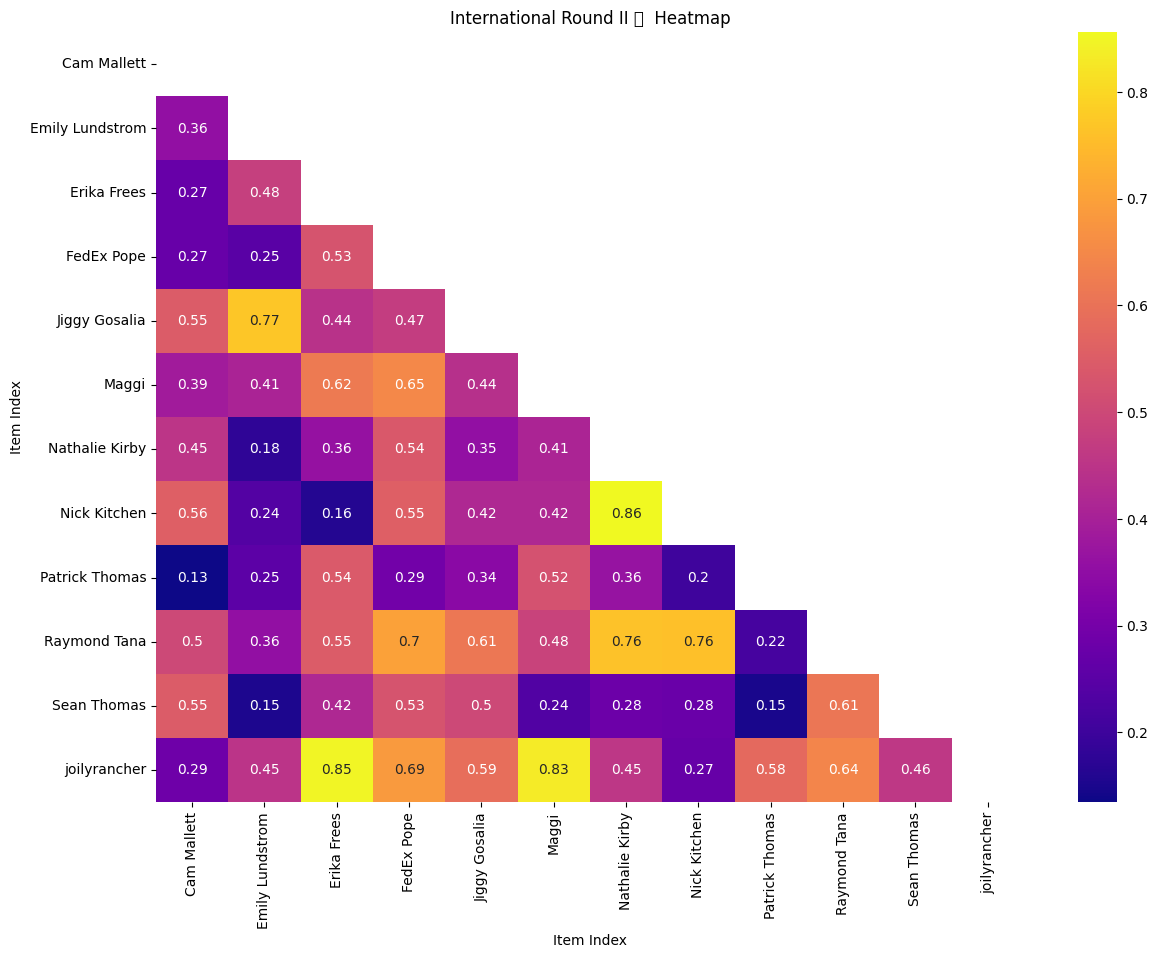

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127786 (\N{CLOUD WITH TORNADO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


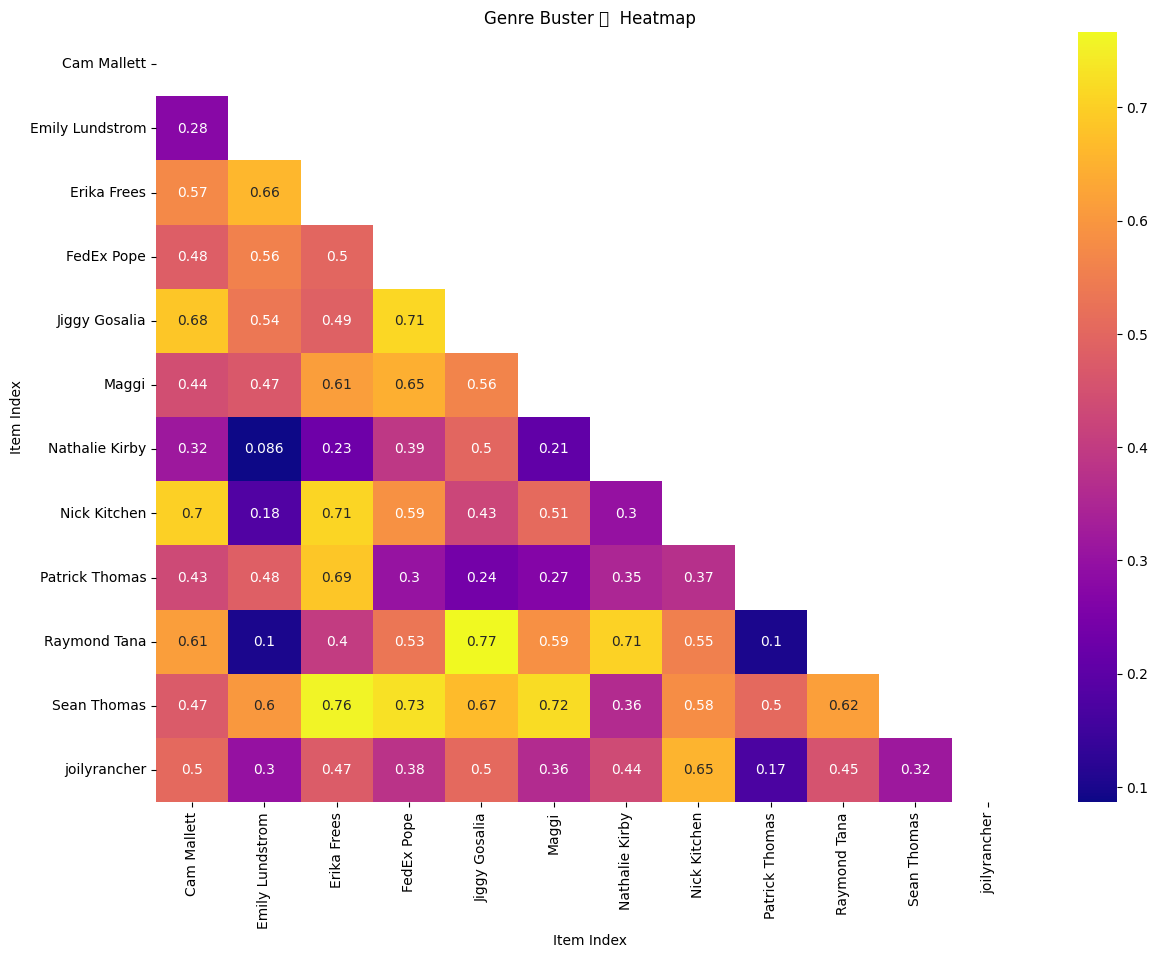

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127908 (\N{MICROPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


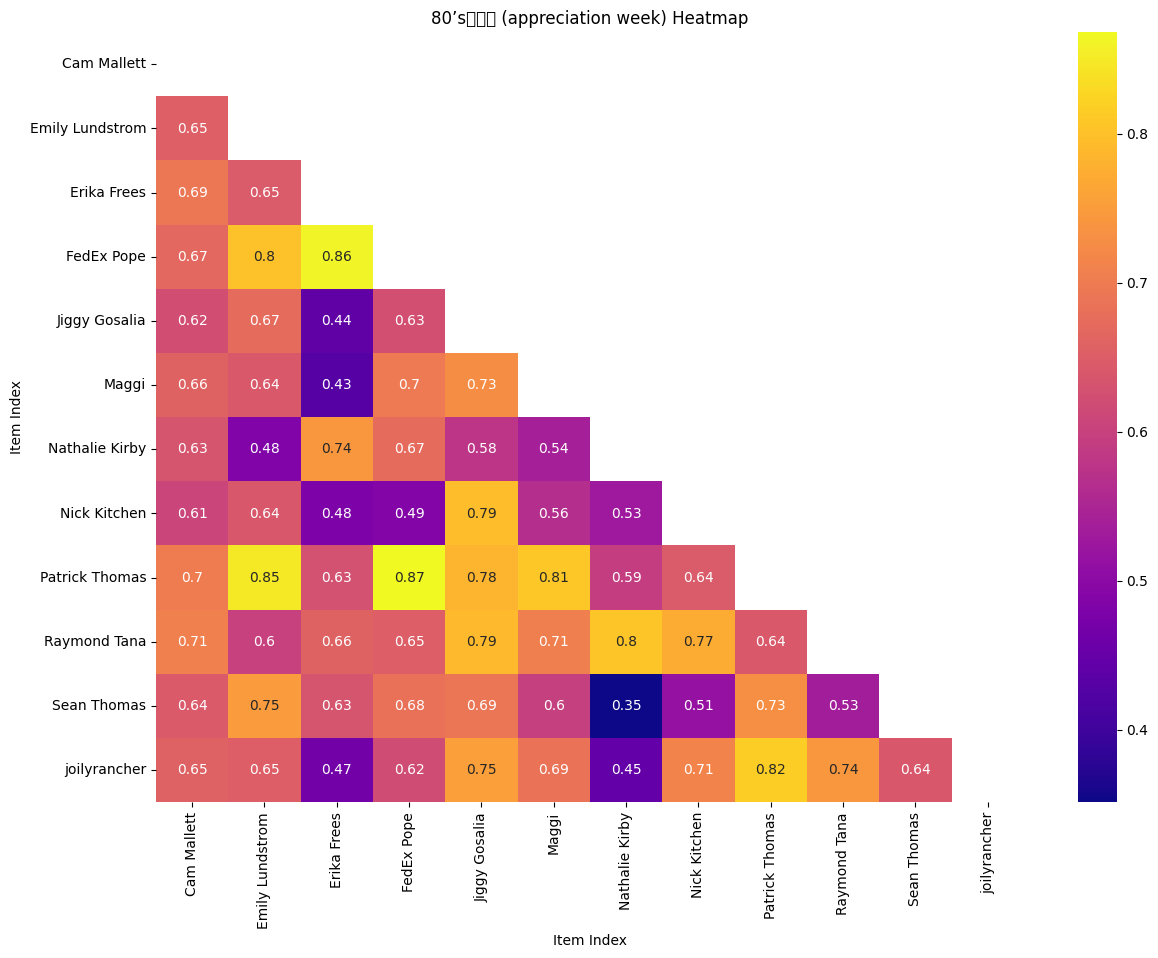

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


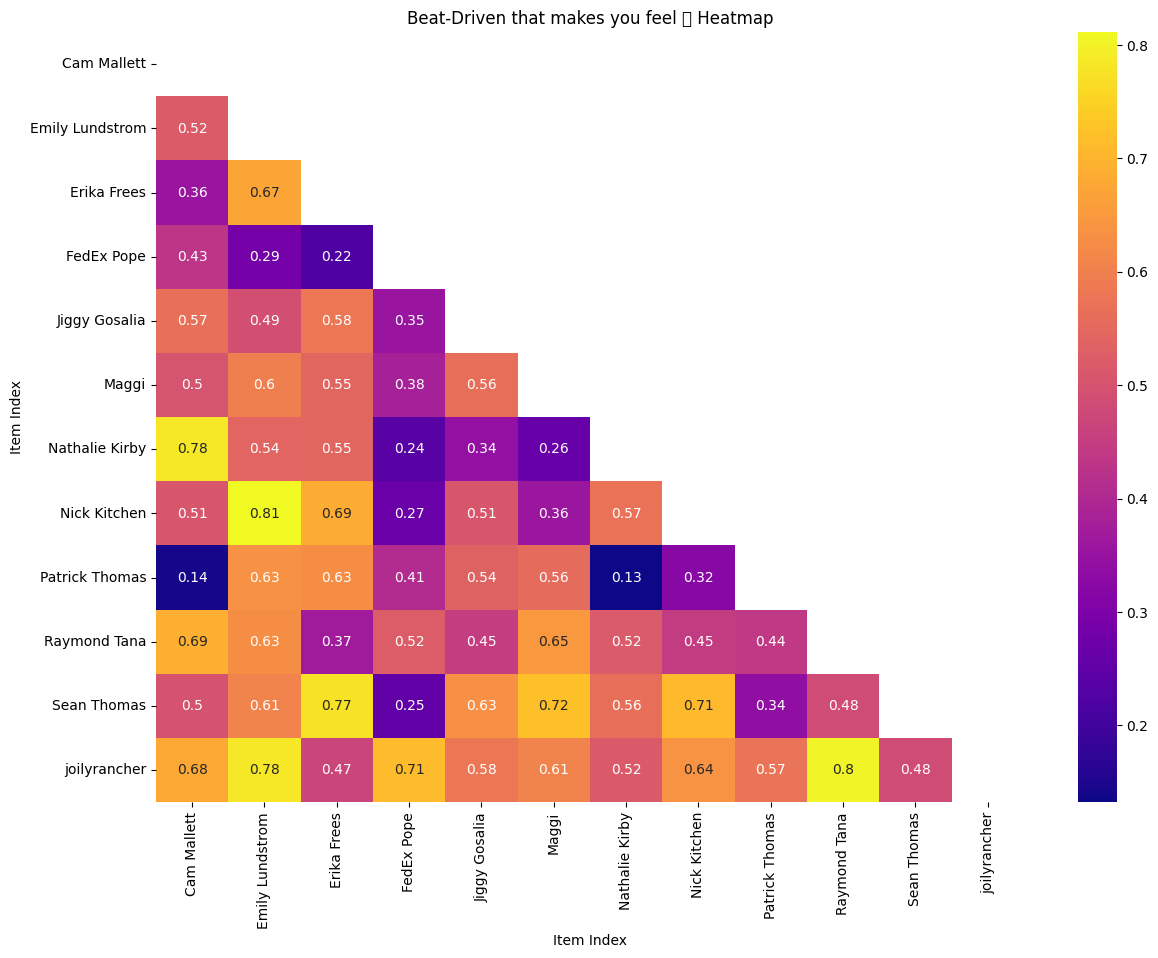

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129767 (\N{BUBBLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


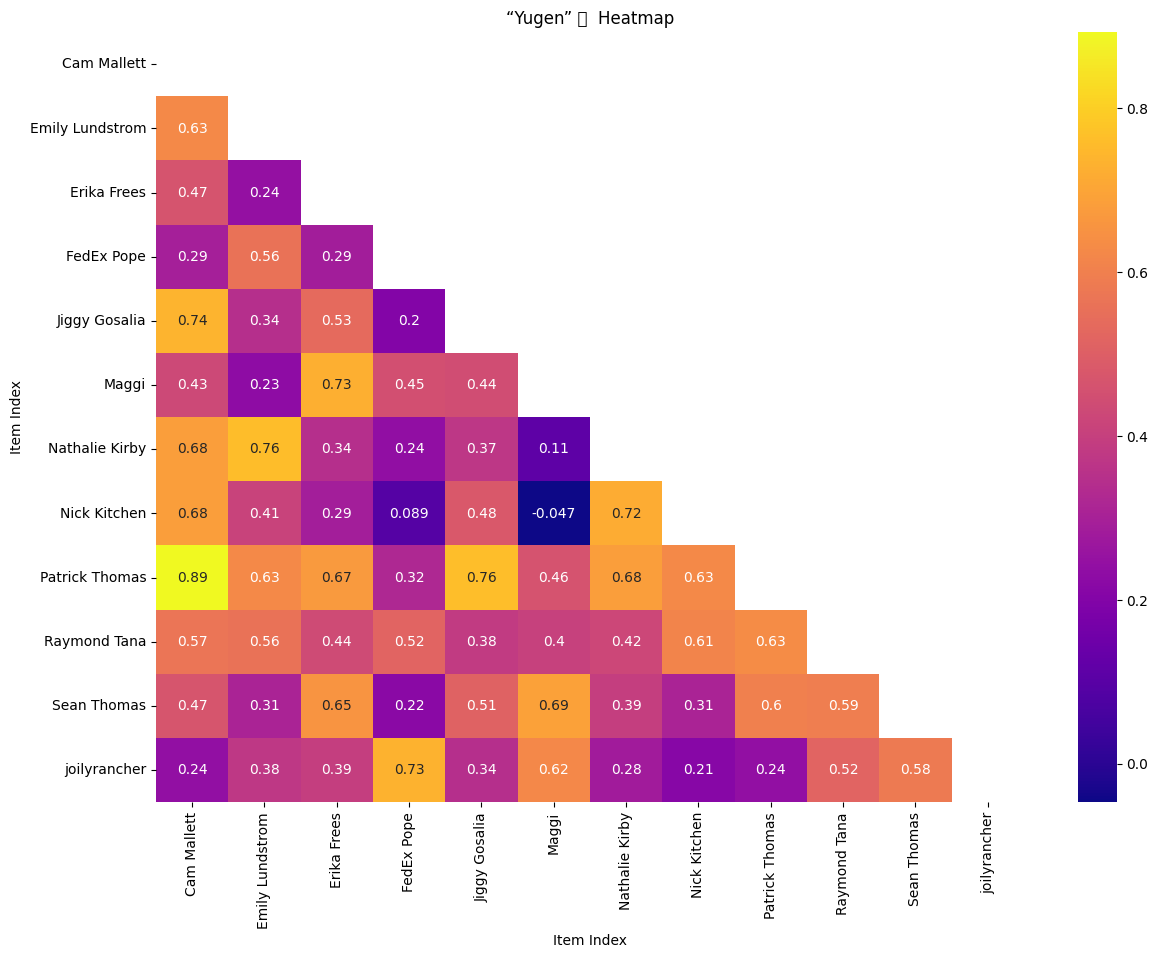

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


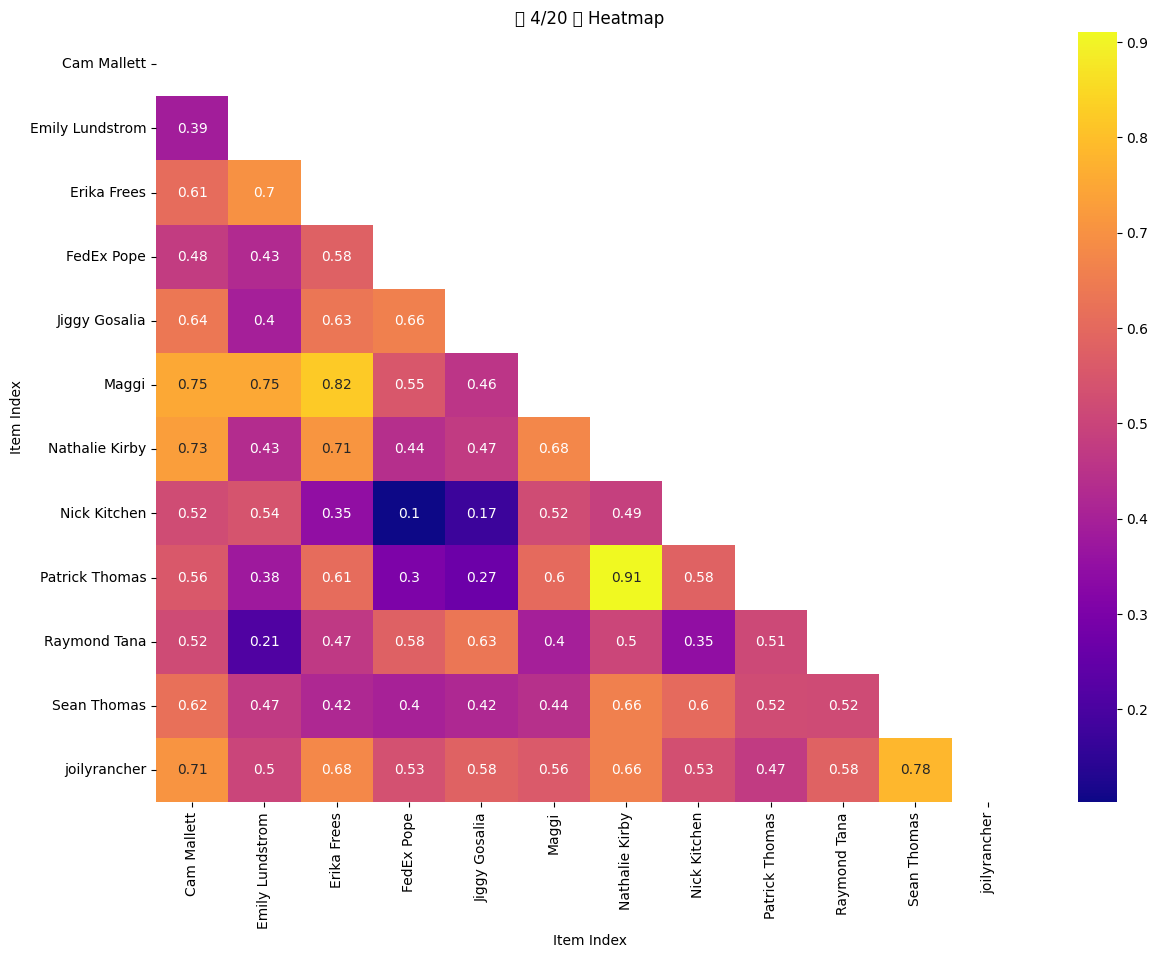

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


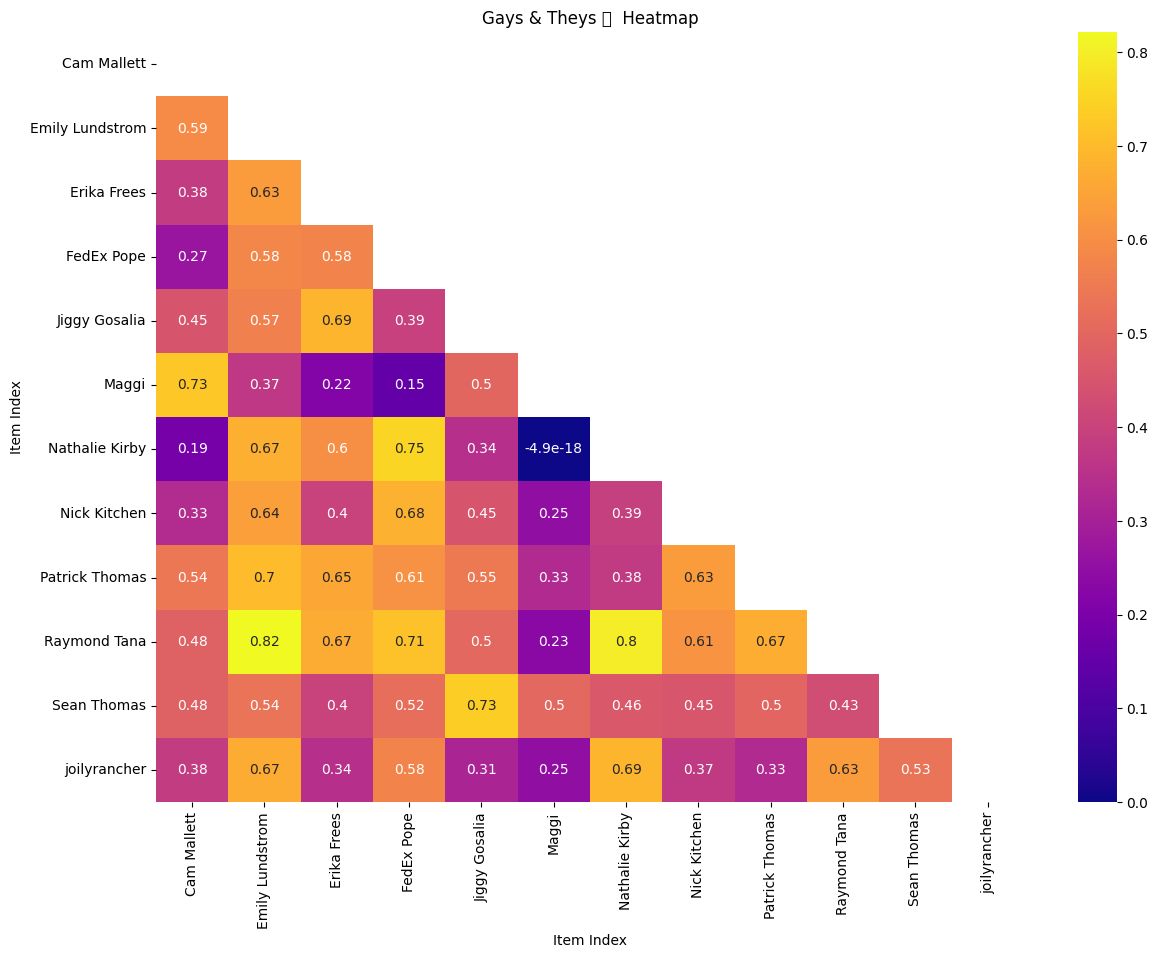

c:\Users\ajwin\Projects\SpotifyPlaylistBot\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


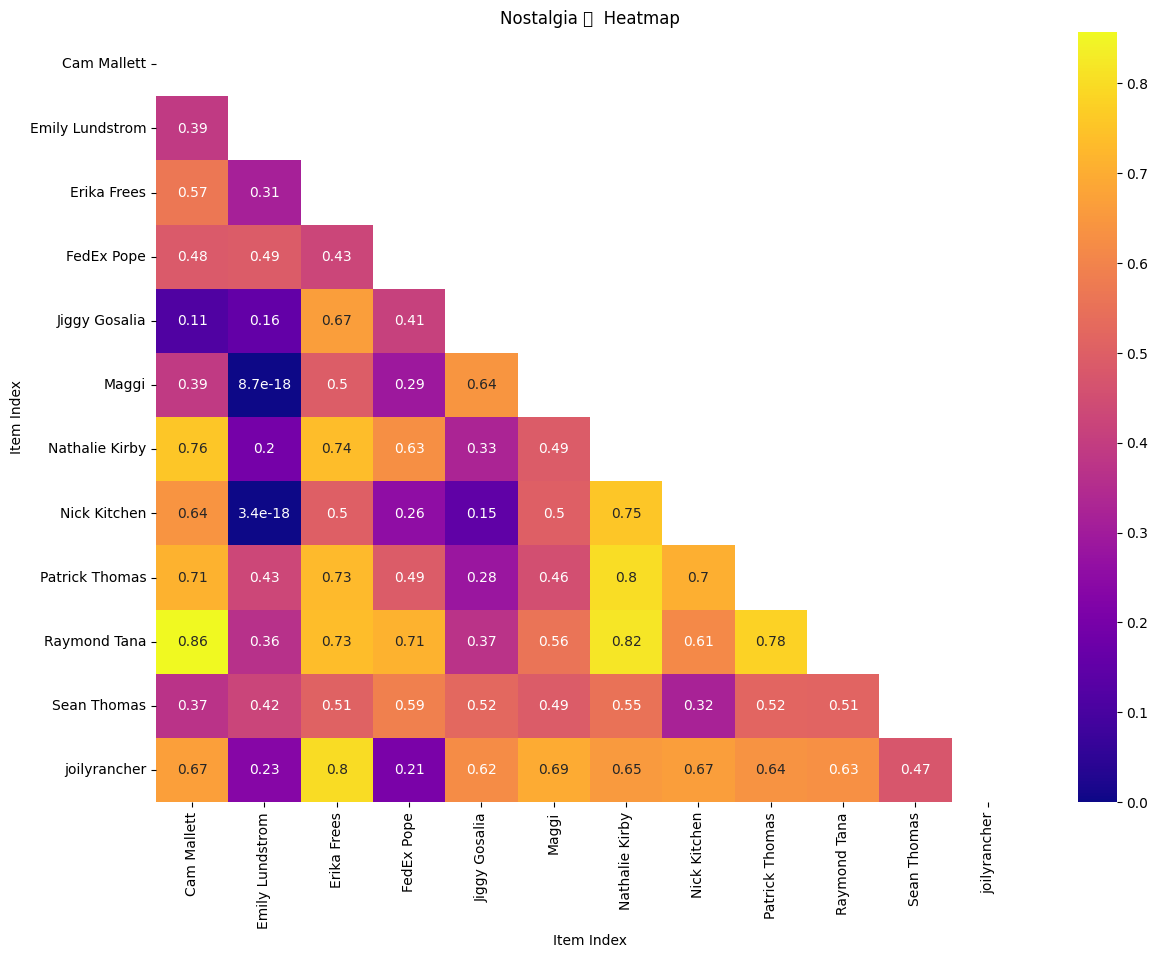

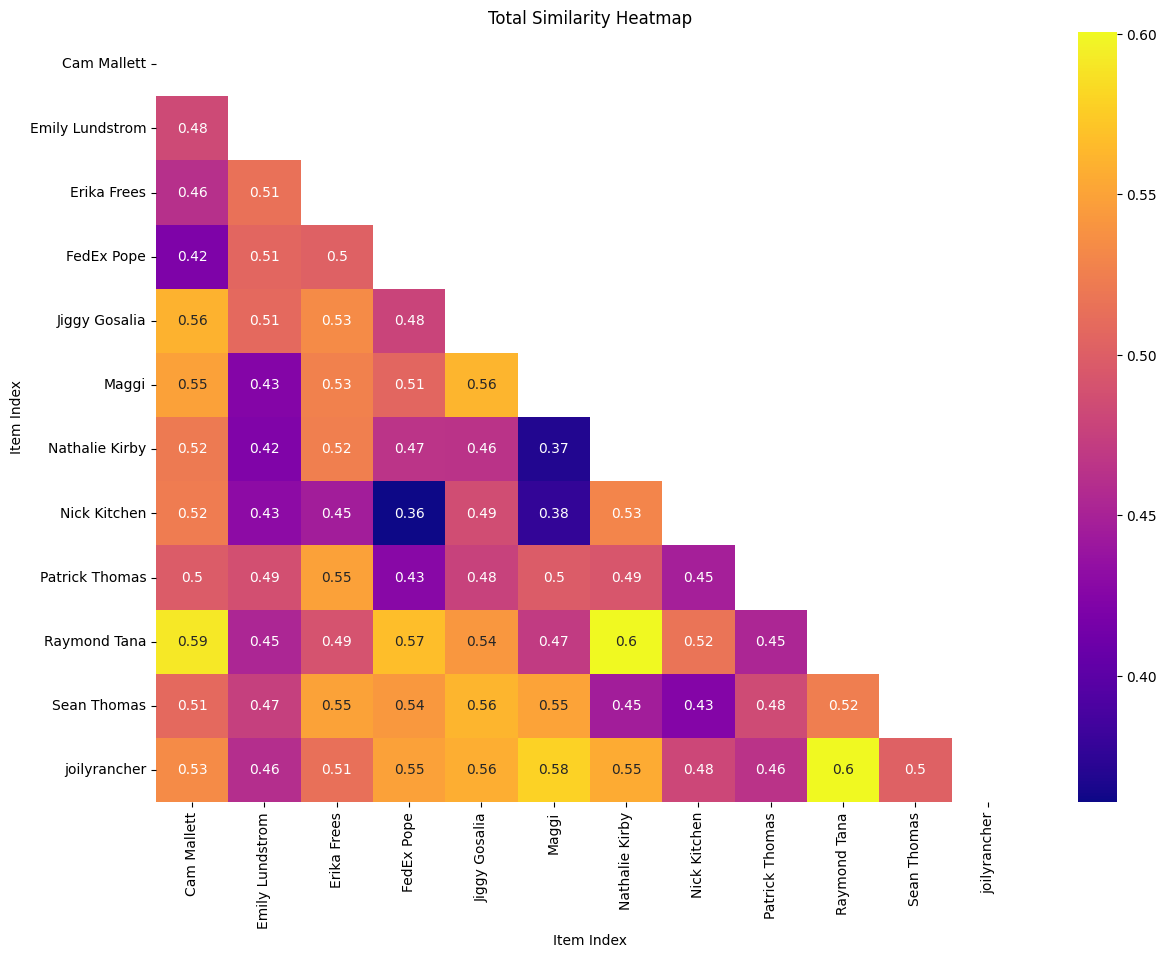

In [16]:
# Create a pivot table of Points Assigned by Voter ID and Song
outdir = r"C:\Users\ajwin\Projects\SpotifyPlaylistBot\musicleague\figures&tables\spring2025"
for i in vote['Round'].unique():
    filename = i
    # Remove problematic characters
    safe_filename = re.sub(r'[\\/:"*?<>|]', '_', filename)
    safe_filename = safe_filename.encode('ascii', 'ignore').decode()
    
    voter = vote[vote['Round'] == i]

    pivot = voter.pivot_table(
        index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
    )

    # Compute the similarity matrix (cosine similarity)
    similarity_matrix = cosine_similarity(pivot)
    #similarity_matrix = np.dot(pivot, pivot.T)

    # Convert the matrix to a DataFrame for easier manipulation
    similarity_df = pd.DataFrame(
        similarity_matrix, index=pivot.index, columns=pivot.index
    )
    mask = np.triu(np.ones_like(similarity_df, dtype=bool))

    similarity_df.to_csv('similarity_df.csv')

    plt.figure(figsize=(14, 10))
    sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

    # Add labels
    plt.title("{} Heatmap".format(i))
    plt.xlabel("Item Index")
    plt.ylabel("Item Index")
    plt.savefig(outdir+'\heatmap {}.png'.format(safe_filename))
    # Show plot
    #plt.show()


pivot = vote.pivot_table(
    index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
)

# Compute the similarity matrix (cosine similarity)
similarity_matrix = cosine_similarity(pivot)
#similarity_matrix = np.dot(pivot, pivot.T)

# Convert the matrix to a DataFrame for easier manipulation
similarity_df = pd.DataFrame(
    similarity_matrix, index=pivot.index, columns=pivot.index
)
mask = np.triu(np.ones_like(similarity_df, dtype=bool))

similarity_df.to_csv('similarity_df.csv')

plt.figure(figsize=(14, 10))
sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

# Add labels
plt.title("{} Heatmap".format("Total Similarity"))
plt.xlabel("Item Index")
plt.ylabel("Item Index")
plt.savefig(outdir+'heatmap {}.png'.format('Total Similarity'))
# Show plot
#plt.show()

In [55]:

# # Create a graph using NetworkX
# G = nx.Graph()

# # Add nodes (Voter IDs)
# for voter in similarity_df.index:
#     G.add_node(voter)

# # Add weighted edges based on similarity
# for i, voter1 in enumerate(similarity_df.index):
#     for j, voter2 in enumerate(similarity_df.columns):
#         if i != j:  # Exclude self-similarity
#             weight = similarity_df.iloc[i, j]
#             if weight > 0:  # Add an edge only if there’s some similarity
#                 G.add_edge(voter1, voter2, weight=weight**2)

# # Use a force-directed layout (spring layout) where edge weights determine proximity
# pos = nx.spring_layout(G, weight='weight', seed=42)

# # Visualize the graph
# plt.figure(figsize=(12, 12))
# nx.draw(
#     G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
#     node_size=3000, font_size=10, font_weight='bold'
# )

# # Add edge labels to show weights
# edge_labels = nx.get_edge_attributes(G, 'weight')
# edge_labels = {key: f"{value:.2f}" for key, value in edge_labels.items()}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# plt.title("Voting Similarity Network (Proximity Based on Strength of Similarity)")
# plt.savefig('../output/network graph fall songs.png')
# #plt.show()

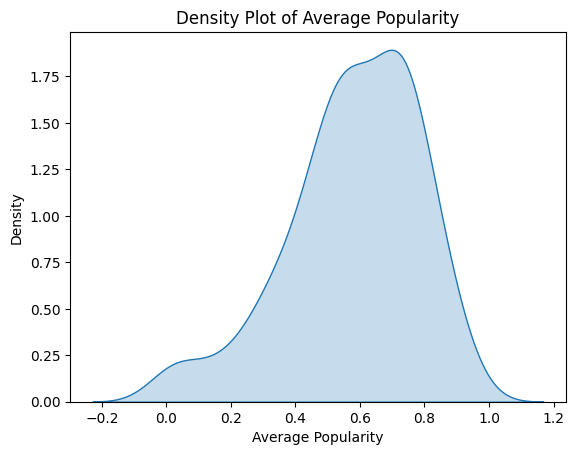

In [101]:
sns.kdeplot(data=grouped_by_song, x='Average Popularity', fill=True)
plt.title('Density Plot of Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Density')
plt.show()

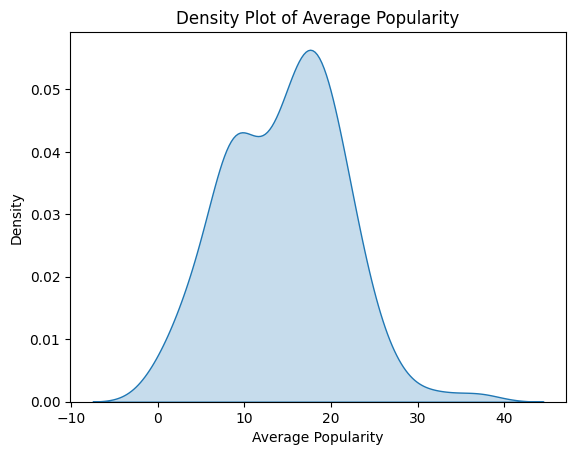

In [102]:
sns.kdeplot(data=grouped_by_song, x='Total Points', fill=True)
plt.title('Density Plot of Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Density')
plt.show()

In [24]:
value_counts = vote['Points Assigned'].value_counts().sort_index()


In [103]:
similarity_df.mean().sort_values()

Name
Nick Kitchen       0.501847
Emily Lundstrom    0.513689
Patrick Thomas     0.523000
FedEx Pope         0.527206
Nathalie Kirby     0.532501
Maggi              0.534446
Sean Thomas        0.547442
Erika Frees        0.550881
Cam Mallett        0.554019
Jiggy Gosalia      0.560721
joilyrancher       0.566141
Raymond Tana       0.567389
dtype: float64

In [ ]:
vote[(vote['Name'] == 'Sean Thomas') & (vote['Comment'].notnull())]

In [ ]:
vote.groupby(['Submitter Name'])['Comment'].agg('count').sort_values()

In [ ]:
import statsmodels.api as sm

# Define the independent variable (PopularityZ) and dependent variable (Total Points)
X = grouped_by_song['PopularityZ']
y = grouped_by_song['TotalPointsZ']

# Add a constant to the independent variable for the regression
X = sm.add_constant(X)

# Perform the linear regression
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())

# Create a scatter plot with the regression line
plt.figure(figsize=(10, 6))
plt.scatter(grouped_by_song['PopularityZ'], grouped_by_song['TotalPointsZ'], alpha=0.7, label='Data Points')
plt.plot(grouped_by_song['PopularityZ'], model.predict(X), color='red', label='Regression Line')
plt.title('Linear Regression: Total Points vs. PopularityZ')
plt.xlabel('PopularityZ')
plt.ylabel('Total Points')
plt.legend()
plt.show()

In [ ]:
#filtered_vote = vote[vote['Round'] != 'Survival 🔪 Week (TV show theme songs)']
most_negative_points = vote[vote['Points Assigned'] == -1].groupby('Submitter Name').size().sort_values(ascending=False)
print(most_negative_points)